Samantha Asefi (sma9am@virginia.edu)
DS 5001
8 May 2026

#imports

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import re
from nltk.corpus import stopwords 
from sklearn.decomposition import LatentDirichletAllocation

import plotly.express as px


In [2]:
from pathlib import Path

OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
CHAPS = OHCO[:2]

f4_dir = Path('corpus/f4')
f5_dir = Path('corpus/f5')
VOCAB = pd.read_csv(f4_dir / 'VOCAB.csv', index_col='term_str')
DTCM  = pd.read_csv(f4_dir / 'DTCM.csv',  index_col=CHAPS)


## Config
claude code recommended

In [3]:
OHCO  = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
CHAPS = OHCO[:2]

n_topics    = 4 # 1 per author, but we can experiment with more
n_iters     = 500 # claude suggestion to do less iterations for testing, but we can do more for final runs
alpha       = 0.01
beta        = 0.1
N_TOP_WORDS = 10
gradient_cmap = 'YlGnBu'

AUTHOR_MAP = {
    'luxemburg_reform-or-revolution':          'Rosa Luxemburg',
    'mao_on-guerrilla-warfare':                'Mao Zedong',
    'mao_correcting-mistaken-ideas':           'Mao Zedong',
    'mao_tactics-against-japanese-imperialism':'Mao Zedong',
    'mao_on-practice':                         'Mao Zedong',
    'mao_win-the-masses':                      'Mao Zedong',
    'marx_communist-manifesto':                'Karl Marx & Friedrich Engels',
    'marx_wage-labour-and-capital':            'Karl Marx',
    'fourier_selections':                      'Charles Fourier'
}

TITLE_MAP = {
    'luxemburg_reform-or-revolution':          'Reform or Revolution',
    'mao_on-guerrilla-warfare':                'On Guerrilla Warfare',
    'mao_correcting-mistaken-ideas':           'On Correcting Mistaken Ideas in the Party',
    'mao_tactics-against-japanese-imperialism':'On Tactics Against Japanese Imperialism',
    'mao_on-practice':                         'On Practice',
    'mao_win-the-masses':                      'Win the Masses for the Anti-Japanese Front',
    'marx_communist-manifesto':                'The Communist Manifesto',
    'marx_wage-labour-and-capital':            'Wage Labour and Capital',
    'fourier_selections':                      'Selections from his Writings'
}


# Scikit Learn LDA

## the code in class took too long to run and the topics couldn't properly be separated, so I have chosen to dive deep into sci-kit learn strategy of lda

In [4]:
min_df = 5
mask = (DTCM > 0).sum(axis=0) >= min_df
DTCM_filtered = DTCM.loc[:, mask]

print(f'Vocab reduced from {DTCM.shape[1]} to {DTCM_filtered.shape[1]} terms')


Vocab reduced from 9668 to 1787 terms


In [5]:
lda = LatentDirichletAllocation(
    n_components=n_topics,
    max_iter=n_iters,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)

lda.fit(DTCM_filtered.values)
print('Perplexity:', round(lda.perplexity(DTCM_filtered.values), 2))

Perplexity: 467.9


In [6]:
topic_cols = [f'T{i:02d}' for i in range(n_topics)]
topic_names = list(range(n_topics))

# PHI: term x topic — sklearn stores as (n_topics x n_terms), so transpose
# Normalise each column so values = P(term | topic)
phi_raw = lda.components_                              # (n_topics, n_terms)
phi_norm = phi_raw / phi_raw.sum(axis=1, keepdims=True)  # row-normalise

PHI_norm = pd.DataFrame(
    phi_norm.T,                                        # (n_terms, n_topics)
    index=DTCM_filtered.columns,
    columns=topic_cols
)
PHI_norm.index.name = 'term_id'

# THETA: topic x doc
theta_raw = lda.transform(DTCM_filtered.values)        # (n_docs, n_topics)
THETA_norm = pd.DataFrame(
    theta_raw.T,                                       # (n_topics, n_docs)
    index=topic_cols,
    columns=pd.MultiIndex.from_tuples(DTCM_filtered.index, names=CHAPS)
)

print('PHI_norm shape:  ', PHI_norm.shape,   '  (term x topic)')
print('THETA_norm shape:', THETA_norm.shape, '  (topic x doc)')


PHI_norm shape:   (1787, 4)   (term x topic)
THETA_norm shape: (4, 63)   (topic x doc)


In [7]:
id_to_str = VOCAB.reset_index()[['term_str']].reset_index()
id_to_str.columns = ['term_id', 'term_str']
id_to_str = id_to_str.set_index('term_id')['term_str']

PHI_norm.index = PHI_norm.index.astype(int)
PHI_norm['term_str'] = PHI_norm.index.map(id_to_str)

In [8]:
print('-' * 70)
for t in topic_cols:
    top = PHI_norm.sort_values(t, ascending=False).head(N_TOP_WORDS)[['term_str', t]]
    print(f'\n{t}:')
    print(top.to_string(index=False))
print('-' * 70)


----------------------------------------------------------------------

T00:
  term_str      T00
  straight 0.033131
  regiment 0.020006
    seizes 0.018090
     surer 0.016951
 assembled 0.016176
practicing 0.015487
 abduction 0.014830
  provoked 0.013624
surpassing 0.013267
   justice 0.012761

T01:
    term_str      T01
   attenuate 0.031206
     sliding 0.023303
      shores 0.015712
   collapses 0.014542
   bonaparte 0.013137
gormandizing 0.010951
    spoiling 0.009871
      seizes 0.008939
    manifold 0.008670
     lemming 0.008658

T02:
  term_str      T02
 assembled 0.046983
  straight 0.032413
 abduction 0.026042
     surer 0.016999
instructed 0.012957
  spacious 0.012541
    robust 0.012487
    hereto 0.011359
  spoiling 0.010693
   slacken 0.010679

T03:
  term_str      T03
   damming 0.019610
filthiness 0.015027
     white 0.012525
 resulting 0.011096
  director 0.009690
  widening 0.009609
    events 0.009276
  stubborn 0.009170
    anyone 0.008675
 bombastic 0.006354
---

In [9]:
print(DTCM.reset_index()['book_id'].value_counts())

book_id
fourier_selections                          27
luxemburg_reform-or-revolution              11
marx_wage-labour-and-capital                10
mao_on-guerrilla-warfare                     7
marx_communist-manifesto                     4
mao_correcting-mistaken-ideas                1
mao_on-practice                              1
mao_tactics-against-japanese-imperialism     1
mao_win-the-masses                           1
Name: count, dtype: int64


/var/folders/c_/g3_6w_vn5vq7d8hqy9pb6tcm0000gn/T/ipykernel_35066/3153187462.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  print(DTCM.reset_index()['book_id'].value_counts())


## Load Data

# Document Topic Table

In [10]:
DOC_TOPIC = THETA_norm.T.copy()
DOC_TOPIC.index.names = CHAPS

DOC_TOPIC['dominant_topic'] = DOC_TOPIC[topic_cols].idxmax(axis=1)
DOC_TOPIC['author'] = DOC_TOPIC.index.get_level_values('book_id').map(AUTHOR_MAP)
DOC_TOPIC['title']  = DOC_TOPIC.index.get_level_values('book_id').map(TITLE_MAP)

DOC_TOPIC.head()


T00       T01       T02       T03  \
book_id            chap_num                                           
fourier_selections 1         0.000292  0.176960  0.026602  0.796145   
                   2         0.000620  0.260822  0.007974  0.730584   
                   3         0.001593  0.288426  0.053248  0.656733   
                   4         0.017124  0.196891  0.091921  0.694064   
                   5         0.006783  0.231740  0.057531  0.703946   

                            dominant_topic           author  \
book_id            chap_num                                   
fourier_selections 1                   T03  Charles Fourier   
                   2                   T03  Charles Fourier   
                   3                   T03  Charles Fourier   
                   4                   T03  Charles Fourier   
                   5                   T03  Charles Fourier   

                                                    title  
book_id            chap_num                                
fourier_selections 1         Selections from his Writings  
                   2         Selections from his Writings  
                   3         Selections from his Writings  
                   4         Selections from his Writings  
                   5         Selections from his Writings

# Heatmap Document x Topic Concentrations

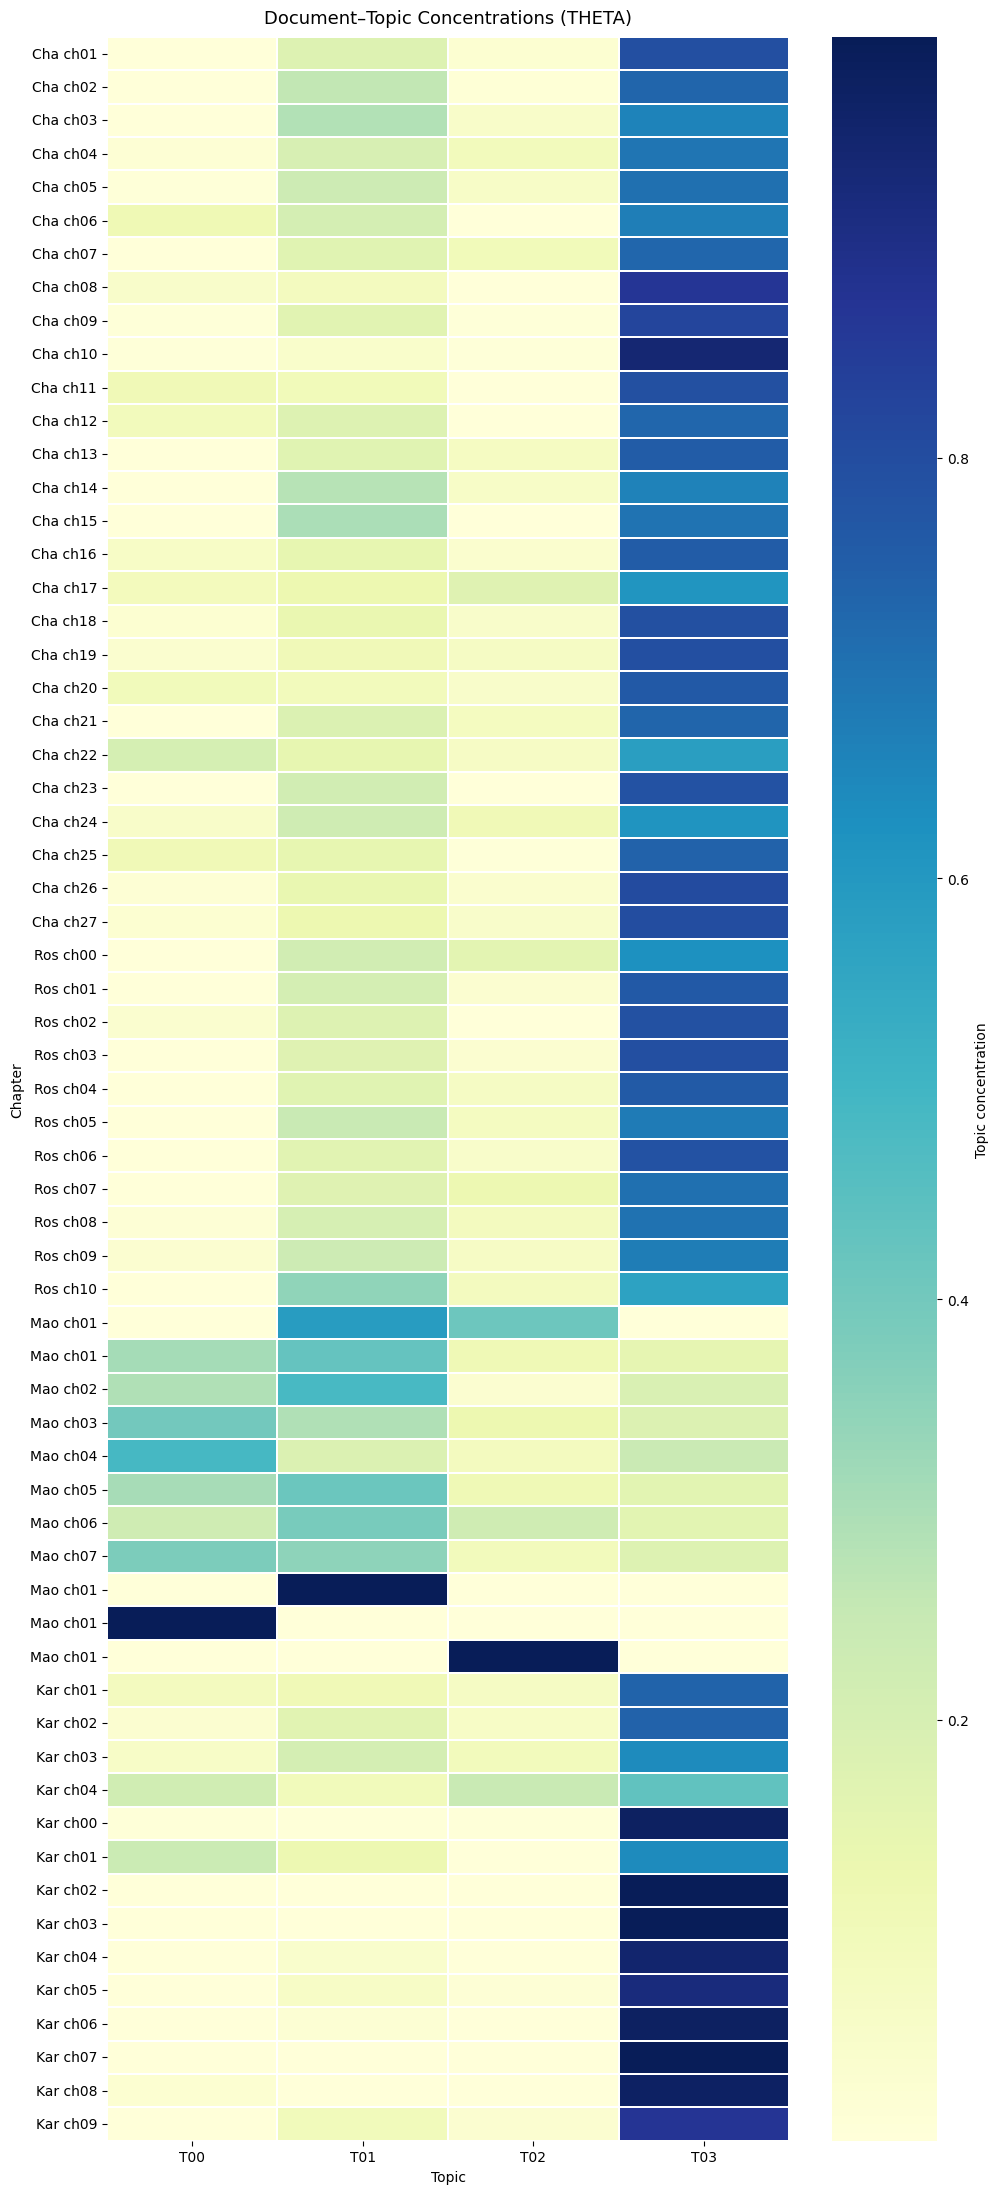

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

heat_data = DOC_TOPIC[topic_cols].copy()
heat_data.index = [
    f"{AUTHOR_MAP.get(b, b)[:3]} ch{c:02d}"
    for b, c in heat_data.index
]

fig, ax = plt.subplots(figsize=(10, max(6, len(heat_data) * 0.35)))
sns.heatmap(heat_data, cmap='YlGnBu', linewidths=.3, linecolor='white', ax=ax,
            cbar_kws={'label': 'Topic concentration'})
ax.set_title('Document–Topic Concentrations (THETA)', fontsize=13, pad=10)
ax.set_xlabel('Topic')
ax.set_ylabel('Chapter')
plt.tight_layout()
plt.savefig(f5_dir / 'lda_theta_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar Char - Dominant Topic by Author

In [12]:
fig = px.histogram(
    DOC_TOPIC.reset_index(),
    x='dominant_topic', color='author', barmode='group',
    title='Dominant Topic per Chapter by Author',
    category_orders={'dominant_topic': topic_cols}
)
fig.show()

# Top Words per Topic

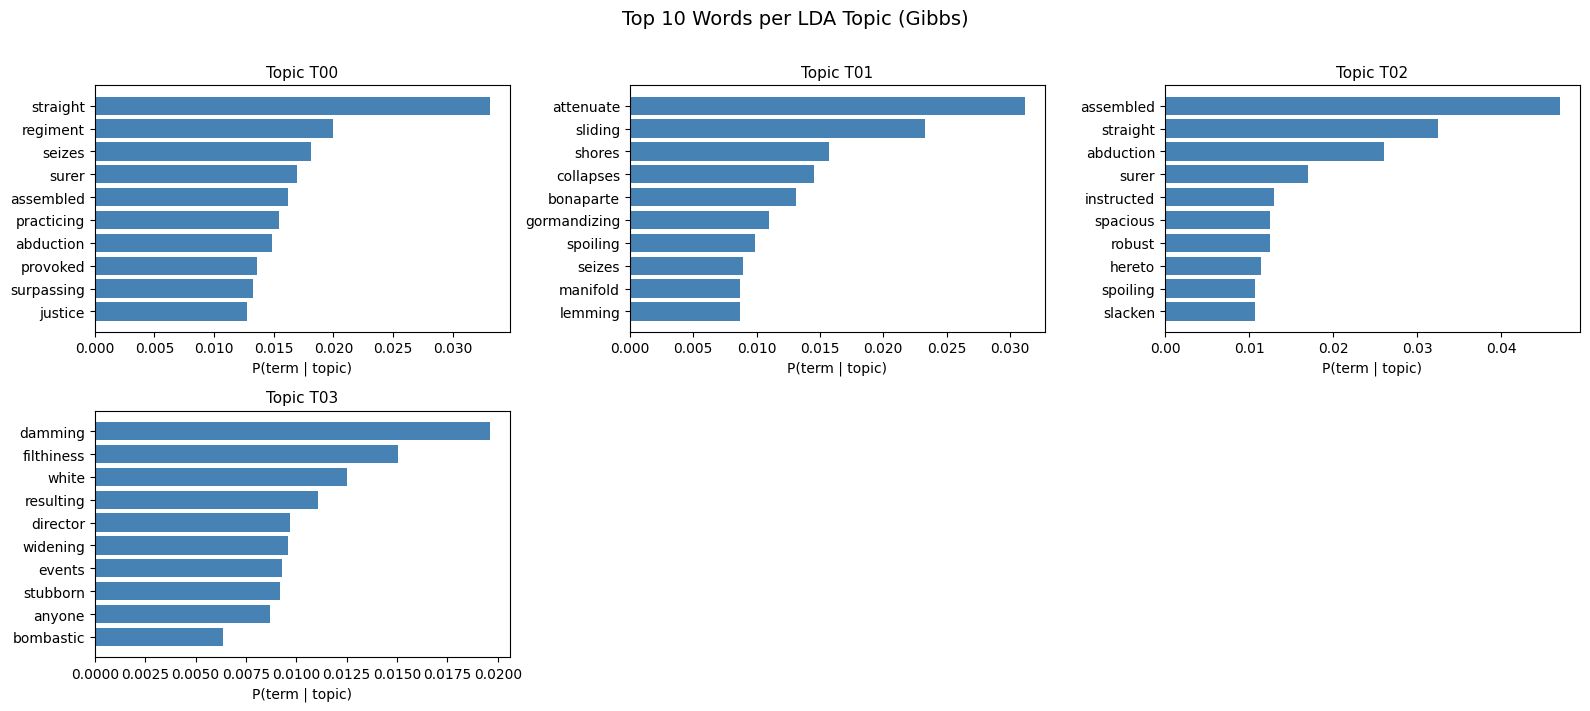

In [13]:
n_cols = 3
n_rows = int(np.ceil(n_topics / n_cols))
PHI_norm['term_str'] = PHI_norm.index.map(id_to_str)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, t in enumerate(topic_cols):
    top = PHI_norm.sort_values(t, ascending=False).head(10)
    axes[i].barh(top['term_str'], top[t], color='steelblue')
    axes[i].invert_yaxis()
    axes[i].set_title(f'Topic {t}', fontsize=11)
    axes[i].set_xlabel('P(term | topic)')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

PHI_norm = PHI_norm.drop(columns='term_str')
plt.suptitle('Top 10 Words per LDA Topic (Gibbs)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f5_dir / 'lda_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# Table 1: Document x Topic concentrations
DOC_TOPIC[topic_cols].to_csv(f5_dir / 'LDA_DOC_TOPIC.csv')

# Table 2: VOCAB_F5 — append LDA topic-term weights
PHI_norm['term_str'] = PHI_norm.index.map(id_to_str)
PHI_str = PHI_norm.set_index('term_str')[topic_cols].copy()
PHI_str.columns = [f'lda_{c}' for c in topic_cols]
PHI_norm = PHI_norm.drop(columns='term_str')

VOCAB_F5 = pd.read_csv(f5_dir / 'VOCAB_F5.csv', index_col='term_str')
VOCAB_F5 = VOCAB_F5.join(PHI_str, how='left')
VOCAB_F5.to_csv(f5_dir / 'VOCAB_F5.csv')

print('LDA_DOC_TOPIC.csv:', DOC_TOPIC[topic_cols].shape)
print('VOCAB_F5.csv:', VOCAB_F5.shape)

LDA_DOC_TOPIC.csv: (63, 4)
VOCAB_F5.csv: (9668, 33)
